# Support Ticket Classification & Prioritization

## Project Overview

This project develops a machine learning system to automatically classify IT support tickets into relevant categories and predict their priority using Natural Language Processing (NLP) and machine learning techniques.

The system uses ticket subject and description text to:
- Classify tickets into support categories
- Predict ticket priority as High, Medium, or Low
- Evaluate model performance using accuracy, precision, recall, and confusion matrices

This solution can help support teams organize incoming tickets and respond to high-priority issues faster.

## 1. Import Libraries

The project uses Pandas for data handling, NLTK for stopword removal, Scikit-learn for TF-IDF feature extraction and machine learning, and Matplotlib/Seaborn for evaluation visualizations.

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BHOOMIKA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## 2. Load the Dataset

The dataset contains IT support tickets with text fields such as subject and body, along with category and priority labels.

In [4]:
df = pd.read_csv("dataset-tickets-multi-lang3-4k.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 17)


,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, \n\nI am reachi...","Dear <name>,\n\nThank you for reaching out reg...",Request,IT Support,high,en,IT Services,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,NaN
4,Problème d'affichage de MacBook Air,Cher équipe de support du magasin en ligne Tec...,"Cher <name>,\n\nMerci de nous avoir contactés ...",Incident,Product Support,low,fr,Tech Online Store,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,NaN


## 3. Data Exploration

Before preprocessing, the target variables are examined to understand the distribution of ticket categories and priority levels.

In [5]:
print("Ticket Categories:")
print(df['queue'].value_counts())

print("\nTicket Priorities:")
print(df['priority'].value_counts())

Ticket Categories:
queue
Technical Support                  1317
Product Support                     690
Customer Service                    627
IT Support                          445
Billing and Payments                338
Returns and Exchanges               197
Service Outages and Maintenance     141
Sales and Pre-Sales                 137
General Inquiry                      55
Human Resources                      53
Name: count, dtype: int64

Ticket Priorities:
priority
high      1649
medium    1603
low        748
Name: count, dtype: int64


## 3.1 Ticket Category Distribution

The distribution of support ticket categories is visualized to understand the volume of tickets handled by each support queue.

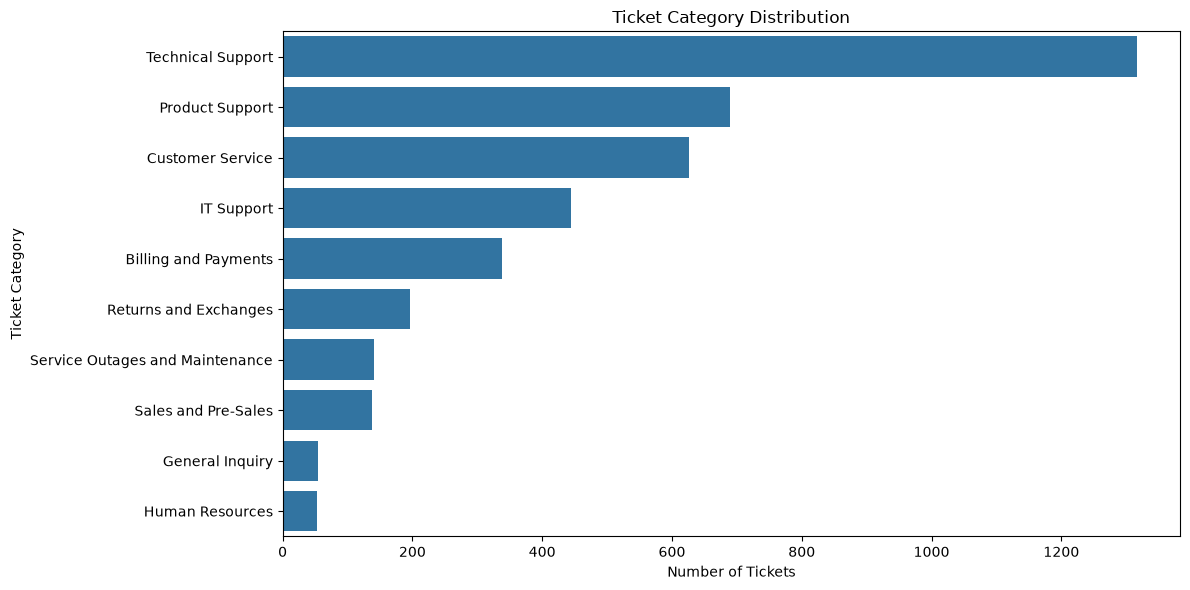

In [20]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='queue',
    order=df['queue'].value_counts().index
)

plt.xlabel("Number of Tickets")
plt.ylabel("Ticket Category")
plt.title("Ticket Category Distribution")
plt.tight_layout()
plt.show()

## 3.2 Ticket Priority Distribution

The distribution of ticket priorities is visualized to understand the proportion of High, Medium, and Low priority support requests.

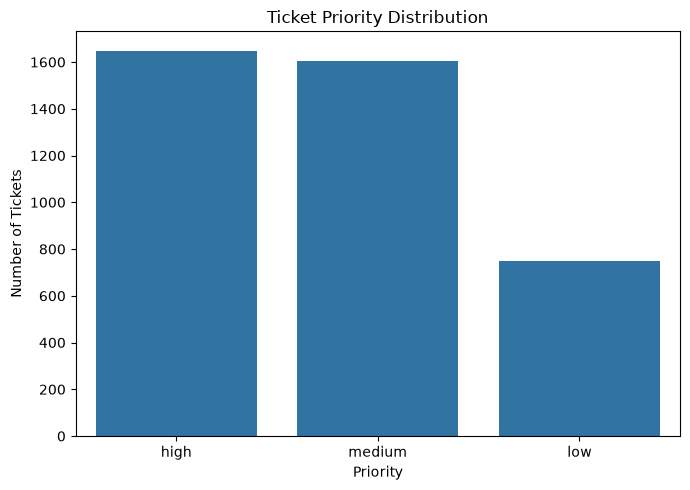

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='priority',
    order=df['priority'].value_counts().index
)

plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.title("Ticket Priority Distribution")
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

The ticket subject and body are combined into a single text field.

The text preprocessing steps include:
- Converting text to lowercase
- Removing punctuation and unnecessary characters
- Removing language-specific stopwords
- Handling missing text values

Only the ticket subject and body are used as input features to avoid using answer or tag fields that could introduce information leakage.

In [6]:
stop_words = set()

for language in ['english', 'german', 'spanish', 'french', 'portuguese']:
    stop_words.update(stopwords.words(language))

data = df[['subject', 'body', 'queue', 'priority', 'language']].copy()

data['subject'] = data['subject'].fillna('')
data['body'] = data['body'].fillna('')

data['text'] = data['subject'] + ' ' + data['body']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-ZÀ-ÿ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

data['clean_text'] = data['text'].apply(clean_text)

## 5. Prepare Training and Testing Data

The cleaned ticket text is used as the input feature.

Two target variables are used:
- `queue` for ticket category classification
- `priority` for priority prediction

The data is divided into training and testing sets using stratified sampling to maintain representative class distributions.

In [7]:
X = data['clean_text']
y_category = data['queue']
y_priority = data['priority']

X_train, X_test, y_category_train, y_category_test, y_priority_train, y_priority_test = train_test_split(
    X,
    y_category,
    y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3200
Testing samples: 800


## 6. TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts the cleaned ticket text into numerical features.

Unigrams and bigrams are used so that the model can learn both individual words and short phrases that may be useful for identifying ticket categories and priority levels.

In [8]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (3200, 20000)
Testing TF-IDF shape: (800, 20000)


## 7. Ticket Category Classification

A Linear Support Vector Machine (LinearSVC) is trained using the TF-IDF features to classify each ticket into its appropriate support category.

The model learns patterns from the ticket subject and body and predicts one of the available support queues.

In [10]:
category_model = LinearSVC(class_weight='balanced', random_state=42)

category_model.fit(X_train_tfidf, y_category_train)

category_pred = category_model.predict(X_test_tfidf)

## 8. Category Classification Evaluation

The category classifier is evaluated using:
- Accuracy
- Weighted Precision
- Weighted Recall
- Classification Report

In [11]:
category_accuracy = accuracy_score(y_category_test, category_pred)
category_precision = precision_score(
    y_category_test,
    category_pred,
    average='weighted',
    zero_division=0
)
category_recall = recall_score(
    y_category_test,
    category_pred,
    average='weighted',
    zero_division=0
)

print("Category Classification Results")
print("--------------------------------")
print("Accuracy :", round(category_accuracy, 4))
print("Precision:", round(category_precision, 4))
print("Recall   :", round(category_recall, 4))

print("\nClassification Report:")
print(classification_report(
    y_category_test,
    category_pred,
    zero_division=0
))

Category Classification Results
--------------------------------
Accuracy : 0.5663
Precision: 0.5558
Recall   : 0.5663

Classification Report:
                                 precision    recall  f1-score   support

           Billing and Payments       0.80      0.94      0.86        68
               Customer Service       0.50      0.50      0.50       125
                General Inquiry       0.25      0.09      0.13        11
                Human Resources       1.00      0.45      0.62        11
                     IT Support       0.30      0.22      0.26        89
                Product Support       0.51      0.51      0.51       138
          Returns and Exchanges       0.65      0.77      0.71        39
            Sales and Pre-Sales       0.67      0.44      0.53        27
Service Outages and Maintenance       0.63      0.43      0.51        28
              Technical Support       0.59      0.67      0.63       264

                       accuracy                     

## 9. Category Confusion Matrix

The confusion matrix shows how correctly the model classifies each ticket category and which categories are most frequently confused with one another.

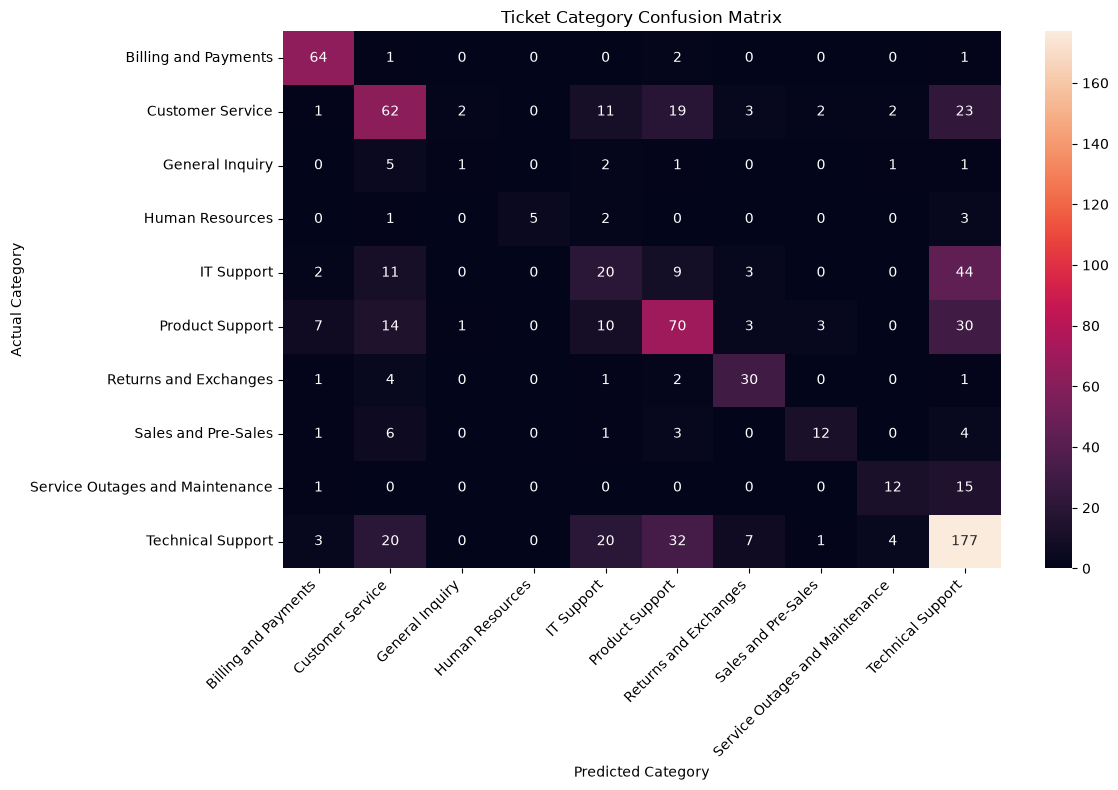

In [12]:
category_cm = confusion_matrix(
    y_category_test,
    category_pred,
    labels=sorted(y_category.unique())
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    category_cm,
    annot=True,
    fmt='d',
    xticklabels=sorted(y_category.unique()),
    yticklabels=sorted(y_category.unique())
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Ticket Category Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Priority Prediction

A second LinearSVC model is trained using the same TF-IDF ticket features to predict ticket priority.

The model predicts three priority levels:
- High
- Medium
- Low

Priority is learned from patterns in the ticket text rather than being assigned manually by a fixed rule.

In [13]:
priority_model = LinearSVC(class_weight='balanced', random_state=42)

priority_model.fit(X_train_tfidf, y_priority_train)

priority_pred = priority_model.predict(X_test_tfidf)

## 11. Priority Prediction Evaluation

The priority prediction model is evaluated using accuracy, precision, recall, and class-wise performance.

In [14]:
priority_accuracy = accuracy_score(y_priority_test, priority_pred)
priority_precision = precision_score(
    y_priority_test,
    priority_pred,
    average='weighted',
    zero_division=0
)
priority_recall = recall_score(
    y_priority_test,
    priority_pred,
    average='weighted',
    zero_division=0
)

print("Priority Prediction Results")
print("---------------------------")
print("Accuracy :", round(priority_accuracy, 4))
print("Precision:", round(priority_precision, 4))
print("Recall   :", round(priority_recall, 4))

print("\nClassification Report:")
print(classification_report(
    y_priority_test,
    priority_pred,
    zero_division=0
))

Priority Prediction Results
---------------------------
Accuracy : 0.5837
Precision: 0.5899
Recall   : 0.5837

Classification Report:
              precision    recall  f1-score   support

        high       0.65      0.71      0.68       306
         low       0.37      0.44      0.40       124
      medium       0.62      0.53      0.57       370

    accuracy                           0.58       800
   macro avg       0.54      0.56      0.55       800
weighted avg       0.59      0.58      0.58       800



## 12. Priority Confusion Matrix

The priority confusion matrix shows how accurately the model distinguishes between High, Medium, and Low priority tickets.

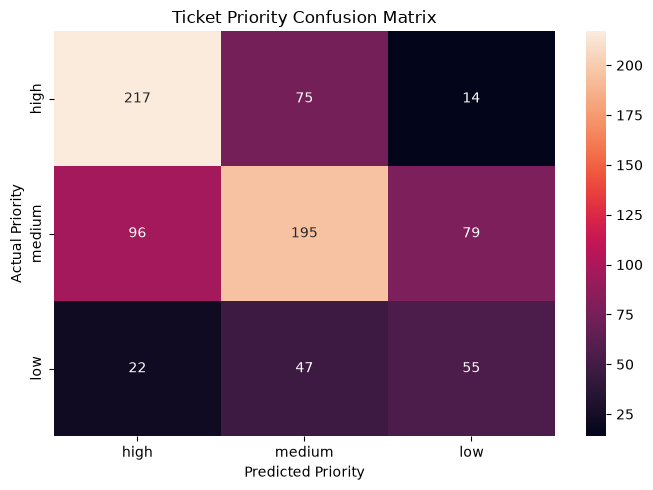

In [15]:
priority_labels = ['high', 'medium', 'low']

priority_cm = confusion_matrix(
    y_priority_test,
    priority_pred,
    labels=priority_labels
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    priority_cm,
    annot=True,
    fmt='d',
    xticklabels=priority_labels,
    yticklabels=priority_labels
)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.title("Ticket Priority Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Model Performance Summary

The final performance of both machine learning models is summarized below.

The category model predicts the appropriate support queue, while the priority model predicts whether a ticket should be treated as High, Medium, or Low priority.

In [16]:
results = pd.DataFrame({
    'Task': [
        'Ticket Category Classification',
        'Priority Prediction'
    ],
    'Accuracy': [
        category_accuracy,
        priority_accuracy
    ],
    'Precision': [
        category_precision,
        priority_precision
    ],
    'Recall': [
        category_recall,
        priority_recall
    ]
})

results

,Task,Accuracy,Precision,Recall
0,Ticket Category Classification,0.56625,0.555771,0.56625
1,Priority Prediction,0.58375,0.589873,0.58375


## 14. Example Ticket Prediction

The trained models can be used on a new support ticket.

The ticket text is first cleaned and converted into TF-IDF features. The category model predicts the appropriate support queue, and the priority model predicts the required priority level.

In [17]:
new_ticket = """
The customer is unable to access the company account and needs immediate assistance.
"""

cleaned_ticket = clean_text(new_ticket)

ticket_tfidf = tfidf.transform([cleaned_ticket])

predicted_category = category_model.predict(ticket_tfidf)[0]
predicted_priority = priority_model.predict(ticket_tfidf)[0]

print("Predicted Category :", predicted_category)
print("Predicted Priority :", predicted_priority)

Predicted Category : Customer Service
Predicted Priority : high


## 15. Business Use

This automated ticket classification and prioritization system can help support managers and SaaS teams by:

- Automatically routing incoming tickets to the appropriate support category
- Identifying high-priority tickets that require faster attention
- Reducing manual ticket sorting
- Improving response organization and support workflow
- Helping support teams handle large volumes of incoming requests efficiently

The system can be integrated into a customer support workflow where new tickets are processed automatically before being assigned to support staff.

## Conclusion

This project demonstrates an NLP-based machine learning solution for support ticket classification and prioritization.

The workflow includes text preprocessing, TF-IDF feature extraction, ticket category classification, priority prediction, and model evaluation using accuracy, precision, recall, classification reports, and confusion matrices.

The resulting system provides a practical foundation for automating support ticket routing and prioritization.